In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv', encoding='latin1')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.shape

(284807, 31)

In [7]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [8]:
df['Class'].head()


,Class
0,0
1,0
2,0
3,0
4,0


In [9]:
df['Class'].unique()

array([0, 1])

In [10]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


/tmp/ipykernel_7462/3875209856.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class',data=df,palette='hls')


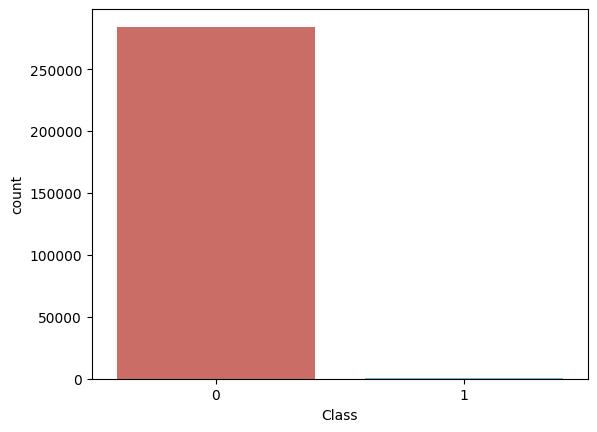

In [11]:
sns.countplot(x='Class',data=df,palette='hls')
plt.show()

In [12]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


In [13]:
#NOW TO ANALYZE TIME COLUMN
df['Time'].describe()

,Time
count,284807.000000
mean,94813.859575
std,47488.145955
min,0.000000
25%,54201.500000
50%,84692.000000
75%,139320.500000
max,172792.000000


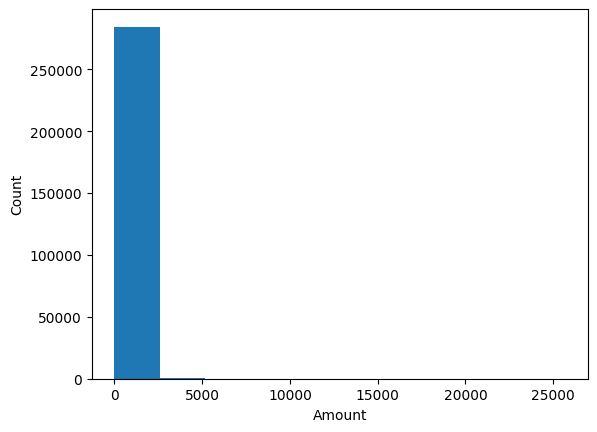

In [14]:
#HISTOGRAM FOR AMOUNT COLUMN
plt.hist(df['Amount'])
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

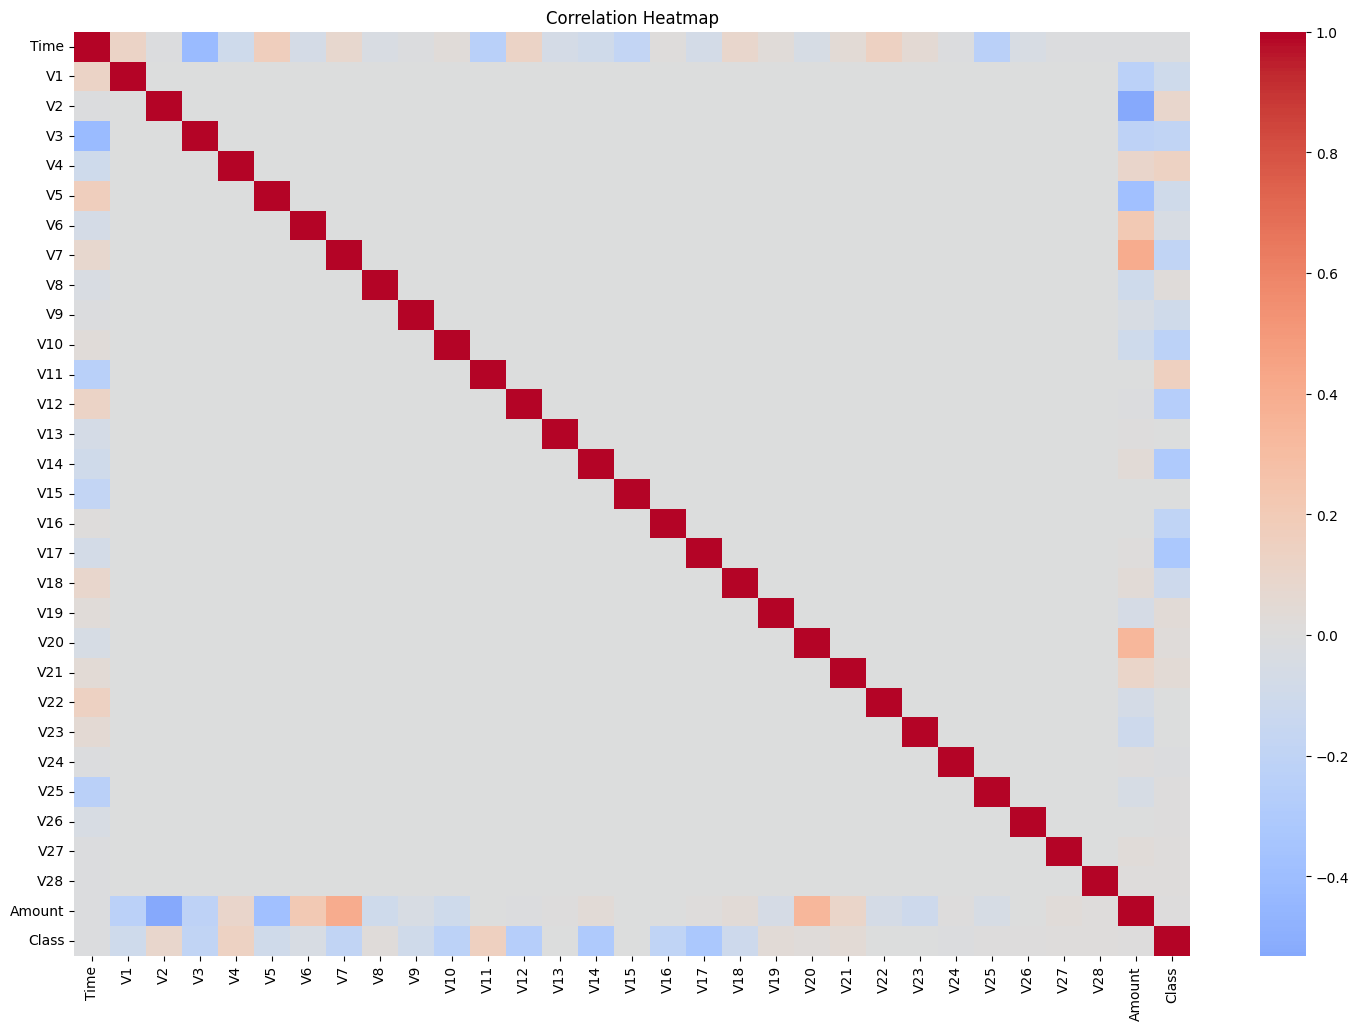

In [15]:
# plt.figure(figsize=(20,15))
# sns.heatmap(df.corr(), cmap='coolwarm')
# plt.title("Correlation Heatmap")
# plt.show()

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(),
            cmap='coolwarm',
            center=0)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
X = df.drop('Class',axis=1)
y=df['Class']

In [17]:
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(227845, 30)
(56962, 30)
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(227845, 30)
(56962, 30)


In [22]:
X_train_scaled[:5]

array([[ 1.41158751e+00,  9.93379083e-01, -4.56036586e-01,
        -8.94051557e-01, -4.67283725e-01,  1.08921729e+00,
         3.02438347e+00, -1.19485202e+00,  9.57057418e-01,
         1.28137638e+00, -1.44546401e-01, -1.10814578e-01,
         5.09338566e-01,  6.21173504e-02, -6.95576832e-02,
         1.45109663e+00,  4.04446404e-01, -9.07403516e-01,
         1.69133453e-01, -5.55365736e-01, -1.73112388e-01,
         1.03171150e-01,  4.09563109e-01,  4.90684977e-01,
         1.14196982e+00, -6.70831980e-01, -8.07226946e-01,
         1.91911522e-01, -9.91057622e-02, -3.22493763e-01],
       [ 6.23140848e-01,  1.03850725e+00, -2.93491180e-02,
        -2.01830171e+00,  1.75133177e-01,  2.13350569e+00,
         2.47884001e+00, -1.83232506e-03,  5.66703699e-01,
         4.11208797e-02,  2.62604208e-01, -2.49329490e-01,
         3.23973351e-01, -4.07235825e-01,  7.54324041e-01,
        -1.63023227e-01, -8.61271777e-01, -3.21276918e-01,
        -8.29392525e-01, -3.37959105e-01, -2.93563756e-

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [24]:
y_pred = lr.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9991397773954567

In [26]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[56851    13]
 [   36    62]]


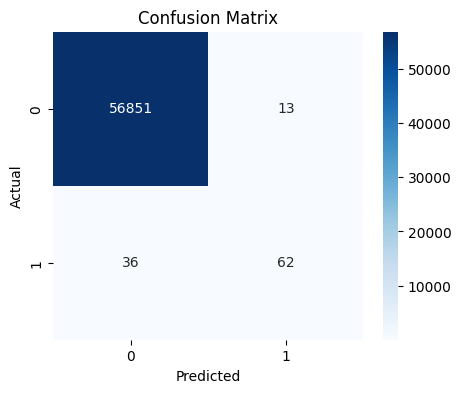

In [27]:
#HEATMAP
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [29]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

In [30]:
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9995611109160493

Confusion Matrix:
[[56859     5]
 [   20    78]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [32]:
!pip install imbalanced-learn

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [39]:
print(y_train.value_counts())
print()
print(y_train_smote.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64

Class
0    227451
1    227451
Name: count, dtype: int64


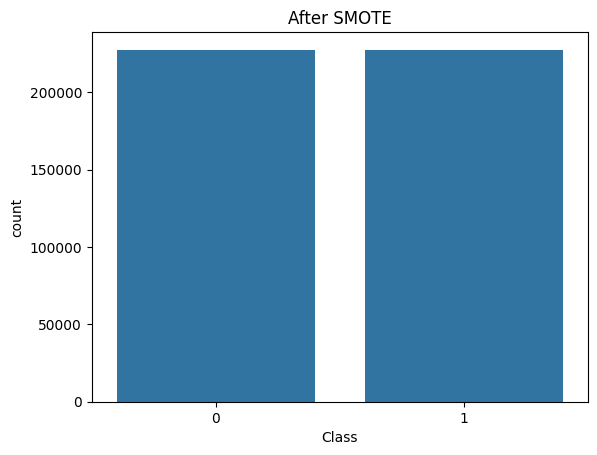

In [40]:
#COUNTPLOT
sns.countplot(x=y_train_smote)
plt.title("After SMOTE")
plt.show()

In [42]:
# RANDOM FOREST + SMOTE
from sklearn.ensemble import RandomForestClassifier
rf_smote = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.999385555282469

Confusion Matrix:
[[56848    16]
 [   19    79]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [44]:
# NOW FIND FEATURE IMPORTANCE
feature_importance = rf.feature_importances_

In [45]:
import pandas as pd
importance_df = pd.DataFrame({
     'Feature': X_train.columns,
     'Importance': feature_importance
     })
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(10)

,Feature,Importance
14,V14,0.261788
17,V17,0.170316
10,V10,0.102715
12,V12,0.080669
16,V16,0.053987
4,V4,0.025080
2,V2,0.024582
21,V21,0.024120
7,V7,0.020737
29,Amount,0.017824


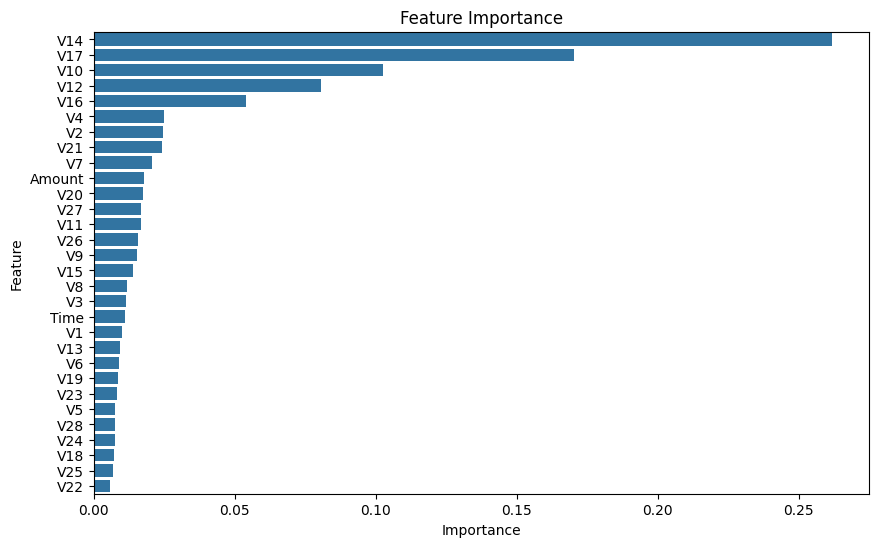

In [46]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()

In [47]:
import pickle

In [48]:
pickle.dump(rf, open('fraud_detection_model.pkl','wb'))

In [49]:
import os
os.path.exists('fraud_detection_model.pkl')

True

In [50]:
loaded_model = pickle.load(open('fraud_detection_model.pkl','rb'))